/Users/blahblahmac/anaconda3/lib/python3.7/site-packages/ipykernel_launcher.py:38: FutureWarning: In v4.0, pm.sample will return an `arviz.InferenceData` object instead of a `MultiTrace` by default. You can pass return_inferencedata=True or return_inferencedata=False to be safe and silence this warning.
Multiprocess sampling (4 chains in 4 jobs)
Metropolis: [theta]


Sampling 4 chains for 1_000 tune and 100_000 draw iterations (4_000 + 400_000 draws total) took 74 seconds.
The number of effective samples is smaller than 25% for some parameters.


AttributeError: 'Polygon' object has no property 'normed'

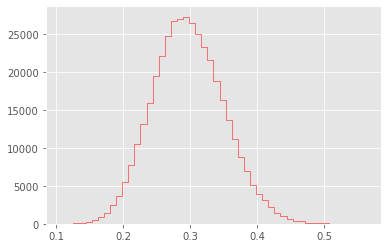

In [2]:
import matplotlib.pyplot as plt
import numpy as np
import pymc3
import scipy.stats as stats

plt.style.use("ggplot")

# Parameter values for prior and analytic posterior
n = 50
z = 10
alpha = 12
beta = 12
alpha_post = 22
beta_post = 52

# How many iterations of the Metropolis 
# algorithm to carry out for MCMC
iterations = 100000

# Use PyMC3 to construct a model context
basic_model = pymc3.Model()
with basic_model:
    # Define our prior belief about the fairness
    # of the coin using a Beta distribution
    theta = pymc3.Beta("theta", alpha=alpha, beta=beta)

    # Define the Bernoulli likelihood function
    y = pymc3.Binomial("y", n=n, p=theta, observed=z)

    # Carry out the MCMC analysis using the Metropolis algorithm
    # Use Maximum A Posteriori (MAP) optimisation as initial value for MCMC
    start = pymc3.find_MAP() 

    # Use the Metropolis algorithm (as opposed to NUTS or HMC, etc.)
    step = pymc3.Metropolis()

    # Calculate the trace
    trace = pymc3.sample(iterations, step, start, random_seed=1, progressbar=True)

# Plot the posterior histogram from MCMC analysis
bins=50
plt.hist(
    trace["theta"], bins, 
    histtype="step", normed=True, 
    label="Posterior (MCMC)", color="red"
)

# Plot the analytic prior and posterior beta distributions
x = np.linspace(0, 1, 100)
plt.plot(
    x, stats.beta.pdf(x, alpha, beta), 
    "--", label="Prior", color="blue"
)
plt.plot(
    x, stats.beta.pdf(x, alpha_post, beta_post), 
    label='Posterior (Analytic)', color="green"
)

# Update the graph labels
plt.legend(title="Parameters", loc="best")
plt.xlabel("$\\theta$, Fairness")
plt.ylabel("Density")
plt.show()

# Show the trace plot
pymc3.traceplot(trace)
plt.show()

In [ ]:
from astropy import wcs
from astropy.io import fits
import numpy as np
import os
import pickle
from astropy.stats import SigmaClip
from photutils import StdBackgroundRMS
import random
import statistics
from mpi4py import MPI



comm = MPI.COMM_WORLD
size = comm.Get_size()
rank = comm.Get_rank()

inp = np.load('/home/kunal/vega/app/nparray/input.npy')
#loading ra and dec from input saved by the dash app
ra = inp[0]
dec = inp[1]

#Getting the names of files
named = os.listdir('/home/kunal/vega/app/dat/dif/')
namep = os.listdir('/home/kunal/vega/app/dat/psf/')
#no  of images / processor
npo  = len(named)//size

mog = pymc.Uniform('m', -1e6 , 1e6,

# Then, define the probability distribution that you would like to sample.
def lnprob(p, vec):
    
    p = np.log(1/(np.sqrt(2*np.pi*(temp**2 + sigmaog**2)))) - ((datad - magog*datap)/(2*(temp**2 + sigmaog**2)))**2
    return -0.5 * N * np.log(2 * np.pi) - N * np.log(p[1]) - 0.5 \
                                    * np.sum(( (vec - p[0]) / p[1] ) ** 2)
def lnprior1(p):
    
    mog, sog = p
    if (-1e6 < m < 1e6 and  -10 < b < 10 and -10 < amp < 10 and
            -5 < loc < 5 and 0 < sig2 < 3):
        return 0.0
    return -np.inf

def lnprior(theta):
    a, b, c = theta
    #flat priors on b, c
    if not 1.0 < b < 2.0 and 1.0 < c < 2.0:
        return -np.inf
    #gaussian prior on a
    mu = 10
    sigma = 1
    return np.log(1.0/(np.sqrt(2*np.pi)*sigma))-0.5*(a-mu)**2/sigma**2

In [ ]:
'''
#load file using astropy
def load(filename):
    
    # Load the FITS hdulist using astropy.io.fits
    hdulist = fits.open(filename)
    w = wcs.WCS(hdulist[1].header)
    data = hdulist[1].data
    date = hdulist[1].header['OBSMJD ']
    ga = hdulist[1].header['GAIN']
    fid = hdulist[1].header['FILTERID']
    
    if fid == 1:
        fid = 'g'
    if fid == 2:
        fid = 'r'
    if fid == 3:
        fid = 'i'
        
    zp = hdulist[1].header['MAGZP']
    uzp = hdulist[1].header['MAGZPUNC']
    hdulist.close()
    return data, date, w, ga, fid, zp, uzp

# Function to perform photometry
def par(nr):
  
    data, date, w, ga, fid, zp, uzp = load('/home/kunal/vega/app/dat/dif/' + named[nr])
    datad = data[10:15,10:15]
    hdu = fits.open('/home/kunal/vega/app/dat/psf/' + namep[nr],mode='readonly', ignore_missing_end=True)
    datap = hdu[0].data
    hdu.close()
    datap = datap[10:15,10:15]
    sigma_clip = SigmaClip(sigma=3.0)
    bkgrms = StdBackgroundRMS(sigma_clip)
    bkg = bkgrms.calc_background_rms(datad)
    
    datad = [item for sublist in datad for item in sublist]
    datap = [item for sublist in datap for item in sublist]
    datad = np.asarray(datad, dtype=np.float64)
    datap = np.asarray(datap, dtype=np.float64)
    temp = datad
    temp = np.where(temp<0.0,0.0,temp)
    temp = np.sqrt((temp/ga) + bkg**2)
    
    p = np.log(1/(np.sqrt(2*np.pi*(temp**2 + sigmaog**2)))) - ((datad - magog*datap)/(2*(temp**2 + sigmaog**2)))**2
    
    for i in range(len(tmag)):
        
        l = (np.log(1/(np.sqrt(2*np.pi*temp**2))) - ((datad - (tmag[i]*datap))/(2*temp**2))**2)
        l = np.sum(l)        
        like.append(l)
        
    sig = statistics.stdev(like)
    
    fo = 10**(0.4*zp)
    sigfo = fo*np.log(10)*uzp/2.5

    fr = mag/fo
    sigr = np.sqrt((sig/fo)**2 + (mag*sigfo/fo**2)**2)  
    
    if fr > 3 * sigr:
     
      mag = -2.5*np.log10(fr)
      sigp = -2.5*np.log10(1-(sigr/fr))
      sign = 2.5*np.log10(1+(sigr/fr)) 
      mlim =  float("NAN")

    else:
      
      mlim = -2.5 * np.log10(3*sigr)
      mag = float("NAN")
      sigp = float("NAN")
      sign = float("NAN")
    
    return mag,sigp,sign,date,fid,mlim
            
    
    
comm.Barrier()

mag =[]
date= []
fid = []
no = []
sigp = []
sign = []
mlim = []

for i in range(rank*npo,(rank+1)*npo):
    
    try:            
        m, sp, sn, d, f, lim = par(i)
        mag.append(m)
        date.append(d)
        fid.append(f)
        no.append(i)
        sigp.append(sp)
        sign.append(sn)
        mlim.append(lim)
    except:
        continue
   
   
comm.Barrier()
data = comm.gather([mag,sigp,sign,date,fid,no,mlim], root=0)

if rank == 0:
    
    mag =[]
    sigp = []
    sign = []
    date= []
    fid = []
    no = []
    mlim = []

    for i in range(len(data)):
        
        temp = data[i]
        mag.append(temp[0])
        sigp.append(temp[1])
        sign.append(temp[2])
        date.append(temp[3])
        fid.append(temp[4])
        no.append(temp[5])
        mlim.append(temp[6])

    mag = [val for sublist in mag for val in sublist]
    sigp = [val for sublist in sigp for val in sublist]
    sign = [val for sublist in sign for val in sublist]
    date = [val for sublist in date for val in sublist]
    fid = [val for sublist in fid for val in sublist]
    no = [val for sublist in no for val in sublist]
    mlim = [val for sublist in mlim for val in sublist]

    with open("/home/kunal/vega/app/nparray/mag.txt", "wb") as fp:  # Pickling
        pickle.dump(mag, fp)
    with open("/home/kunal/vega/app/nparray/date.txt", "wb") as fp:  # Pickling
        pickle.dump(date, fp)
    with open("/home/kunal/vega/app/nparray/sigp.txt", "wb") as fp:  # Pickling
        pickle.dump(sigp, fp)
    with open("/home/kunal/vega/app/nparray/sign.txt", "wb") as fp:  # Pickling
        pickle.dump(sign, fp)
    with open("/home/kunal/vega/app/nparray/no.txt", "wb") as fp:  # Pickling
        pickle.dump(no, fp)
    with open("/home/kunal/vega/app/nparray/fid.txt", "wb") as fp:  # Pickling
        pickle.dump(fid, fp)
    with open("/home/kunal/vega/app/nparray/mlim.txt", "wb") as fp:  # Pickling
        pickle.dump(mlim, fp)


'''